### 서울시 행정동별 요양시설 유효공급 격차 ④ E2SFCA 접근성

자치구 집계는 다른 구 시설을 이용하는 경우를 반영하지 못한다. 본 노트북은 이용 반경과 거리감쇠를 반영하는 E2SFCA(Luo & Qi, 2009)로 행정동별 '유효 공급 접근성'을 계산한다.

- 1단계(시설 쪽): $R_j = S_j \,/\, \sum_{d_{ij} \le d_0} D_i \, W(d_{ij})$ — 시설 j 반경 안의 가중 수요 1명당 유효 정원
- 2단계(동 쪽): $A_i = \sum_{d_{ij} \le d_0} R_j \, W(d_{ij})$ — 동 i 주민(1~2등급) 1명이 닿을 수 있는 유효 정원
- 거리감쇠: $W(d) = [e^{-\frac12 (d/d_0)^2} - e^{-\frac12}] \,/\, [1 - e^{-\frac12}]$ ($d \le d_0$), 그 밖에는 0

### 1. 분석 기준

- 수요 $D_i$: 02 노트북의 동별 추정 1~2등급 인정자(주 결과: 버전 A)
- 공급 $S_j$: 03 노트북의 정원 × 품질 가중치(주 결과: 가동률 비, 미평가는 서울 평균 q)
- 지점: 수요는 행정동 중심점, 공급은 시설 좌표. 거리는 EPSG:5179 직선거리
- 반경: 기본 $d_0 = 5$km, 민감도 3km·10km
- 범위: 서울·경기·인천의 모든 행정동과 입소시설로 계산하고, 결과는 서울 동만 보고한다. 두 단계 계산이므로 서울 동에서 최대 반경의 두 배 안의 수요·공급이 모두 범위 안에 있어야 하며, 이를 assert로 확인한다.
- 단위: $A_i \times 100$ = **1~2등급 인정자 100명당 유효 정원(석)**

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy.stats import spearmanr

import config as C
import e2sfca as E

pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["font.family"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

DEMAND_COL = {"A": "D_A", "B": "D_B"}[C.DEMAND_VERSION] + ("3" if C.INCLUDE_GRADE3 else "")
SUPPLY_COL = f"S_{C.Q_METHOD}_{C.UNRATED_Q}"
print(f"주 결과 설정: 수요 {DEMAND_COL}, 공급 {SUPPLY_COL}, d0 = {C.D0_KM}km, 감쇠 {C.DECAY}")

주 결과 설정: 수요 D_A, 공급 S_occupancy_seoul_mean, d0 = 5km, 감쇠 gaussian


### 2. 자료와 거리 행렬

In [2]:
dong = gpd.read_file(C.OUTPUT_DIR / "행정동_분석범위.gpkg")
demand = pd.read_csv(C.OUTPUT_DIR / "동별_수요.csv", dtype={"행정동코드": str})
dong = dong.merge(
    demand[["행정동코드", "지역", "D_A", "D_B", "D_BEB", "D_A3", "D_B3"]], on="행정동코드", validate="one_to_one"
)
dong["65세이상"] = demand.set_index("행정동코드").loc[dong["행정동코드"], ["65~74세", "75~84세", "85세 이상"]].sum(axis=1).to_numpy()
dong["소수요"] = dong["서울"] & (dong["65세이상"] < C.MIN_POP65)
fac = pd.read_csv(C.OUTPUT_DIR / "시설_공급.csv", dtype={"장기요양기관코드": str, "행정동코드": str})
fac_xy = gpd.GeoSeries(gpd.points_from_xy(fac["lon"], fac["lat"]), crs="EPSG:4326").to_crs(C.CRS)
fac["x"], fac["y"] = fac_xy.x, fac_xy.y

cache_file = C.OUTPUT_DIR / "거리행렬_동x시설.npz"
if cache_file.exists():
    cached = np.load(cache_file, allow_pickle=True)
    same = (list(cached["dong"]) == list(dong["행정동코드"])) and (list(cached["fac"]) == list(fac["장기요양기관코드"]))
else:
    same = False
if same:
    dist = cached["dist"]
else:
    dist = E.distance_matrix_km(dong[["cx", "cy"]].to_numpy(), fac[["x", "y"]].to_numpy())
    np.savez_compressed(cache_file, dist=dist, dong=dong["행정동코드"].to_numpy(), fac=fac["장기요양기관코드"].to_numpy())

seoul = dong["서울"].to_numpy()
assert seoul.sum() == 426 and dist.shape == (len(dong), len(fac))

# 경계 효과 assert: 서울 동에서 2 × 최대 반경 안에 범위 밖 육지가 없어야 한다.
outside = gpd.read_file(C.OUTPUT_DIR / "분석범위_밖_인접육지.gpkg").union_all()
seoul_pts = gpd.GeoSeries(gpd.points_from_xy(dong.loc[seoul, "cx"], dong.loc[seoul, "cy"]), crs=C.CRS)
min_out_km = seoul_pts.distance(outside).min() / 1000
assert min_out_km >= 2 * max(C.D0_SENSITIVITY_KM), min_out_km
print(f"서울 동 중심점에서 범위 밖 육지까지 최단거리 {min_out_km:.1f}km ≥ 2 × {max(C.D0_SENSITIVITY_KM)}km")
print(f"거리 행렬 {dist.shape[0]:,}개 동 × {dist.shape[1]:,}개 시설 (캐시 {'사용' if same else '새로 계산'})")
print(f"서울 동 중심점에서 가장 가까운 시설까지 거리: 중앙값 {np.median(dist[seoul].min(axis=1)):.2f}km, 최대 {dist[seoul].min(axis=1).max():.2f}km")

서울 동 중심점에서 범위 밖 육지까지 최단거리 33.1km ≥ 2 × 15km
거리 행렬 1,183개 동 × 3,160개 시설 (캐시 사용)
서울 동 중심점에서 가장 가까운 시설까지 거리: 중앙값 0.60km, 최대 2.81km


### 3. 주 결과

In [3]:
def run(demand_col=DEMAND_COL, supply_col=SUPPLY_COL, d0=C.D0_KM, decay=C.DECAY, mask_dong=None, mask_fac=None):
    d_idx = np.ones(len(dong), bool) if mask_dong is None else mask_dong
    f_idx = np.ones(len(fac), bool) if mask_fac is None else mask_fac
    D = dong.loc[d_idx, demand_col].to_numpy()
    S = fac.loc[f_idx, supply_col].to_numpy()
    res = E.e2sfca(D, S, dist[np.ix_(d_idx, f_idx)], d0, decay)
    E.check_conservation(res, D, S)  # 보존 성질 assert
    return res


base = run()
dong["A"] = base.accessibility
dong["A100"] = dong["A"] * 100
fac["R"] = base.supply_ratio

lhs, rhs = E.check_conservation(base, dong[DEMAND_COL].to_numpy(), fac[SUPPLY_COL].to_numpy())
no_demand = fac.loc[base.no_demand, ["장기요양기관이름", "시도", "시군구", "정원"]]
display(Markdown(
    f"- 보존 성질: Σ D·A = {lhs:,.1f}, 반경 안 수요가 있는 시설의 Σ S = {rhs:,.1f} (일치)\n"
    f"- 반경 안 수요가 0인 시설: {len(no_demand)}곳, 정원 {no_demand['정원'].sum():,.0f}석 (계산에서 제외)"
))
if len(no_demand):
    display(no_demand)

seoul_dong = dong.loc[seoul].copy()
seoul_dong.drop(columns="geometry").to_csv(C.OUTPUT_DIR / "동별_접근성.csv", index=False)
eligible = seoul_dong.loc[~seoul_dong["소수요"]]  # 하위 목록·분위·지도 색칠 대상
q10, q50, q90 = eligible["A100"].quantile([0.1, 0.5, 0.9])
display(Markdown(
    f"서울 {len(eligible)}개 동(65세 이상 {C.MIN_POP65}명 미만 {seoul_dong['소수요'].sum()}개 동 제외)의 1~2등급 100명당 유효 정원: 중앙값 **{q50:.1f}석**, 하위 10% **{q10:.1f}석 이하**, "
    f"상위 10% **{q90:.1f}석 이상** (P90/P10 = {q90 / q10:.1f}배)"
))
eligible["A100"].describe().to_frame().T

- 보존 성질: Σ D·A = 116,293.7, 반경 안 수요가 있는 시설의 Σ S = 116,293.7 (일치)
- 반경 안 수요가 0인 시설: 13곳, 정원 450석 (계산에서 제외)

,장기요양기관이름,시도,시군구,정원
988,자월 공립 요양원(요양),인천광역시,옹진군,9.00
2393,용인시니어너싱홈,경기도,용인시,29.00
2621,사회복지법인 오로지 종합복지원(미리내요양원),경기도,안성시,90.00
2746,희망실버케어센터,경기도,화성시,29.00
2760,다인너싱홈,경기도,화성시,9.00
3064,늘사랑노인요양공동생활가정,경기도,여주시,9.00
3105,샘물복지타운,경기도,가평군,29.00
3106,백둔리상신노인전문요양원,경기도,가평군,60.00
3118,상면효사랑요양원,경기도,가평군,8.00
3119,밝은집,경기도,양평군,49.00


서울 424개 동(65세 이상 100명 미만 2개 동 제외)의 1~2등급 100명당 유효 정원: 중앙값 **67.5석**, 하위 10% **28.5석 이하**, 상위 10% **109.8석 이상** (P90/P10 = 3.8배)

,count,mean,std,min,25%,50%,75%,max
A100,424.00,67.27,30.05,15.85,40.18,67.46,90.44,159.41


**수요가 매우 작은 동의 처리.** 재건축 등으로 주민이 거의 없는 동은 추정 수요가 0에 가까워 접근성 순위에 올릴 실익이 없고, 우선 공급 대상으로 지목하면 오해를 낳는다. 65세 이상 주민등록인구가 `MIN_POP65`(100명) 미만인 동은 E2SFCA 계산에는 그대로 두되(수요가 0에 가까워 결과에 영향 없음), 하위 목록·분위 계산에서 빼고 지도에는 회색 빗금으로 따로 표시한다. 기준값 100명은 이런 동과 일반 동 사이의 간격(아래 표의 다음 순위 동)을 보고 정했다.

In [4]:
small = seoul_dong.sort_values("65세이상")[["행정동명", "지역", "65세이상", DEMAND_COL, "A100", "소수요"]].head(6)
small["행정동명"] = small["행정동명"].str.split().str[-1]
display(small.rename(columns={DEMAND_COL: "추정 수요", "A100": "100명당 유효 정원"})
        .style.format({"65세이상": "{:,.0f}", "추정 수요": "{:.1f}", "100명당 유효 정원": "{:.1f}"}).hide(axis="index"))
print(f"제외 기준(65세 이상 {C.MIN_POP65}명 미만)에 해당하는 동: {', '.join(seoul_dong.loc[seoul_dong['소수요'], '행정동명'].str.split().str[-1])}")

행정동명,지역,65세이상,추정 수요,100명당 유효 정원,소수요
둔촌1동,강동구,9,0.1,81.4,True
반포본동,서초구,37,0.4,17.3,True
소공동,중구,292,3.5,31.1,False
을지로동,중구,501,6.1,39.6,False
삼청동,종로구,627,9.6,54.2,False
명동,중구,721,9.9,33.9,False


제외 기준(65세 이상 100명 미만)에 해당하는 동: 반포본동, 둔촌1동


In [5]:
bottom_n = int(np.ceil(len(eligible) * 0.1))
bottom = eligible.nsmallest(bottom_n, "A100")
display(Markdown(f"**접근성 하위 10% 동 ({bottom_n}곳)의 자치구 분포**"))
display(bottom.groupby("지역").size().sort_values(ascending=False).rename("동 수").to_frame().T)
display(
    bottom[["행정동명", "지역", DEMAND_COL, "A100"]]
    .assign(행정동명=lambda d: d["행정동명"].str.split().str[-1])
    .rename(columns={DEMAND_COL: "추정 수요", "A100": "100명당 유효 정원"})
    .style.format({"추정 수요": "{:.0f}", "100명당 유효 정원": "{:.1f}"}).hide(axis="index")
)

**접근성 하위 10% 동 (43곳)의 자치구 분포**

지역,용산구,동작구,서초구,관악구,강남구,마포구,송파구,영등포구
동 수,12,8,8,5,3,3,2,2


행정동명,지역,추정 수요,100명당 유효 정원
사당2동,동작구,76,15.8
사당3동,동작구,57,17.1
사당4동,동작구,37,17.5
서빙고동,용산구,38,18.3
이촌1동,용산구,74,18.3
인헌동,관악구,52,18.5
사당1동,동작구,47,18.8
흑석동,동작구,74,19.0
사당5동,동작구,32,20.6
내곡동,서초구,44,20.7


### 4. 동별 접근성 지도

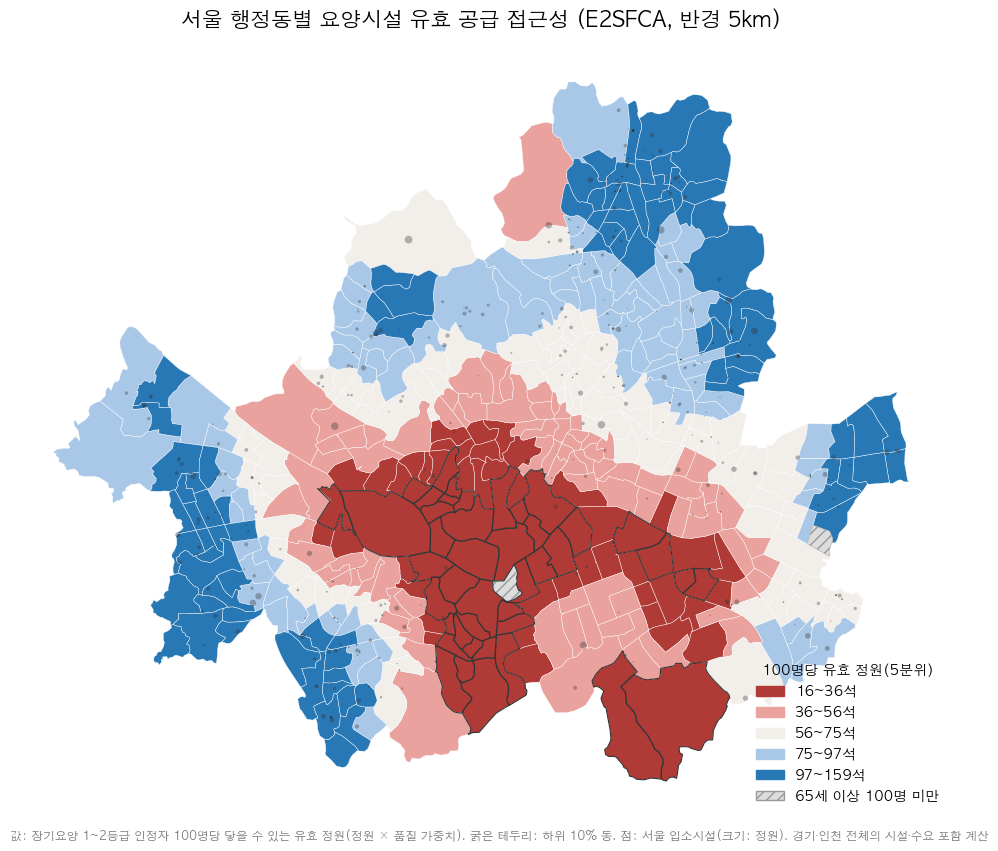

In [6]:
classes = pd.qcut(eligible["A100"], 5)
labels = [f"{iv.left:.0f}~{iv.right:.0f}석" for iv in classes.cat.categories]
seoul_dong["등급"] = classes.cat.rename_categories(labels).reindex(seoul_dong.index)
colors = ["#B03A35", "#E9A29E", "#F2EFEA", "#A9C8E8", "#2878B5"]

fig, ax = plt.subplots(figsize=(11, 9))
for label, color in zip(labels, colors):
    seoul_dong.loc[seoul_dong["등급"] == label].plot(ax=ax, color=color, edgecolor="white", linewidth=0.3, label=label)
seoul_dong.loc[seoul_dong["소수요"]].plot(ax=ax, color="#DDDDDD", edgecolor="#999999", hatch="///", linewidth=0.3)
bottom.boundary.plot(ax=ax, color="#333333", linewidth=0.8)
in_seoul_fac = fac.loc[fac["시도"].eq("서울특별시")]
ax.scatter(in_seoul_fac["x"], in_seoul_fac["y"], s=in_seoul_fac["정원"] / 8, color="#333333", alpha=0.35, linewidth=0)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors]
handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="#DDDDDD", edgecolor="#999999", hatch="///"))
ax.legend(handles, labels + [f"65세 이상 {C.MIN_POP65}명 미만"], title="100명당 유효 정원(5분위)", loc="lower right", frameon=False)
ax.set_title(f"서울 행정동별 요양시설 유효 공급 접근성 (E2SFCA, 반경 {C.D0_KM}km)", fontsize=15, pad=14)
ax.set_axis_off()
ax.text(0, -0.03,
        f"값: 장기요양 1~2등급 인정자 100명당 닿을 수 있는 유효 정원(정원 × 품질 가중치). 굵은 테두리: 하위 10% 동. "
        f"점: 서울 입소시설(크기: 정원). 경기·인천 전체의 시설·수요 포함 계산",
        transform=ax.transAxes, fontsize=8.5, color="#777777")
plt.tight_layout()
fig.savefig(C.OUTPUT_DIR / "동별_접근성_지도.png", dpi=200, bbox_inches="tight")
plt.show()

### 5. 경계 효과 점검

서울 동과 서울 시설만으로 계산하면 경계 근처 동의 결과가 어떻게 달라지는지 확인한다. 버퍼를 넣은 이유를 수치로 보이기 위한 점검이다.

In [7]:
seoul_fac = fac["시도"].eq("서울특별시").to_numpy()
only_seoul = run(mask_dong=seoul, mask_fac=seoul_fac)
seoul_dong["A100_서울만"] = only_seoul.accessibility * 100

boundary = dong.loc[seoul].union_all().boundary
seoul_dong["경계거리_km"] = gpd.GeoSeries(gpd.points_from_xy(seoul_dong["cx"], seoul_dong["cy"]), crs=C.CRS).distance(boundary).to_numpy() / 1000
near = seoul_dong["경계거리_km"] < C.D0_KM
change = seoul_dong["A100_서울만"] / seoul_dong["A100"] - 1
rho_edge = spearmanr(seoul_dong["A100"], seoul_dong["A100_서울만"])[0]
display(Markdown(
    f"- 경계에서 {C.D0_KM}km 안의 서울 동 {near.sum()}개: 서울만으로 계산하면 접근성이 중앙값 {change[near].median():+.1%} "
    f"(범위 {change[near].min():+.1%} ~ {change[near].max():+.1%}) 달라진다.\n"
    f"- 그 밖의 동 {(~near).sum()}개: 중앙값 {change[~near].median():+.1%}\n"
    f"- 두 계산의 서울 동 순위 상관: {rho_edge:.3f}"
))

- 경계에서 5km 안의 서울 동 336개: 서울만으로 계산하면 접근성이 중앙값 +0.6% (범위 -75.0% ~ +33.7%) 달라진다.
- 그 밖의 동 90개: 중앙값 +0.0%
- 두 계산의 서울 동 순위 상관: 0.946

### 6. 민감도 격자

주 결과(반경 5km, 가동률 비 q, 수요 A)와 비교해 반경 × q 방식 × 수요 버전 조합마다 서울 동 순위의 스피어만 상관과 하위 10% 동의 겹침 비율(주 결과 하위 10% 동 중 해당 조합에서도 하위 10%인 비율)을 계산한다. 미평가 처리, 3등급 포함, 거리감쇠 없는 2SFCA는 반경 5km에서 추가로 비교한다.

In [8]:
keep = ~seoul_dong["소수요"].to_numpy()
base_rank = seoul_dong["A100"].to_numpy()[keep]
base_bottom = set(bottom["행정동코드"])
eligible_codes = seoul_dong["행정동코드"].to_numpy()[keep]


def bottom_set(res):
    a = res.accessibility[seoul][keep]
    return set(eligible_codes[np.argsort(a)[:bottom_n]])


def compare(res):
    a = res.accessibility[seoul][keep]
    return spearmanr(base_rank, a)[0], len(bottom_set(res) & base_bottom) / bottom_n


rows = []
for d0 in C.D0_SENSITIVITY_KM:
    for q in ["occupancy", "regression", "binary", "none"]:
        for dv in ["D_A", "D_B"]:
            rho, overlap = compare(run(demand_col=dv, supply_col=f"S_{q}_seoul_mean", d0=d0))
            rows.append({"반경(km)": d0, "q 방식": q, "수요": dv, "미평가": "seoul_mean", "감쇠": "gaussian", "순위 상관": rho, "하위10% 겹침": overlap})
extra = [
    dict(supply_col="S_occupancy_separate", label=("미평가", "separate")),
    dict(supply_col="S_occupancy_rating2025", label=("미평가", "rating2025")),
    dict(demand_col="D_A3", label=("수요", "D_A3")),
    dict(demand_col="D_BEB", label=("수요", "D_BEB")),
    dict(decay="uniform", label=("감쇠", "uniform")),
]
for e in extra:
    key, val = e.pop("label")
    rho, overlap = compare(run(**e))
    row = {"반경(km)": C.D0_KM, "q 방식": "occupancy", "수요": "D_A", "미평가": "seoul_mean", "감쇠": "gaussian"}
    row[key] = val
    rows.append({**row, "순위 상관": rho, "하위10% 겹침": overlap})

sensitivity = pd.DataFrame(rows)
sensitivity.to_csv(C.OUTPUT_DIR / "민감도_격자.csv", index=False)
display(
    sensitivity.style.format({"순위 상관": "{:.3f}", "하위10% 겹침": "{:.0%}"})
    .background_gradient(subset=["순위 상관"], cmap="Blues", vmin=0.5, vmax=1)
    .background_gradient(subset=["하위10% 겹침"], cmap="Blues", vmin=0.3, vmax=1)
    .hide(axis="index")
)

반경(km),q 방식,수요,미평가,감쇠,순위 상관,하위10% 겹침
3,occupancy,D_A,seoul_mean,gaussian,0.866,58%
3,occupancy,D_B,seoul_mean,gaussian,0.832,58%
3,regression,D_A,seoul_mean,gaussian,0.866,58%
3,regression,D_B,seoul_mean,gaussian,0.832,58%
3,binary,D_A,seoul_mean,gaussian,0.847,56%
3,binary,D_B,seoul_mean,gaussian,0.806,53%
3,none,D_A,seoul_mean,gaussian,0.872,58%
3,none,D_B,seoul_mean,gaussian,0.838,56%
5,occupancy,D_A,seoul_mean,gaussian,1.000,100%
5,occupancy,D_B,seoul_mean,gaussian,0.986,81%


In [9]:
pivot = sensitivity.loc[sensitivity["미평가"].eq("seoul_mean") & sensitivity["감쇠"].eq("gaussian") & sensitivity["수요"].isin(["D_A", "D_B"])]
by_d0 = pivot.groupby("반경(km)")[["순위 상관", "하위10% 겹침"]].agg(["min", "median"])
by_other = pivot.loc[pivot["반경(km)"].eq(C.D0_KM)][["순위 상관", "하위10% 겹침"]].agg(["min", "median"])
display(Markdown("**반경별 요약** (q 방식·수요 버전 8개 조합)"))
display(by_d0.style.format("{:.2f}"))

**반경별 요약** (q 방식·수요 버전 8개 조합)

**품질 가중 방식만 바꿨을 때.** 'A·B등급 1, 나머지 0.5'는 가동률 비보다 등급 간 차이를 훨씬 크게 두는 가중이다. 이 버전에서도 동 순위가 유지되는지 따로 본다.

In [10]:
binary_rows = sensitivity.loc[sensitivity["q 방식"].isin(["binary", "none"]) & sensitivity["미평가"].eq("seoul_mean") & sensitivity["감쇠"].eq("gaussian") & sensitivity["수요"].isin(["D_A", "D_B"])]
display(binary_rows.pivot_table(index=["반경(km)", "수요"], columns="q 방식", values=["순위 상관", "하위10% 겹침"])
        .style.format("{:.3f}"))
bin5 = sensitivity.query("`반경(km)` == @C.D0_KM and `q 방식` == 'binary' and 수요 == 'D_A' and 미평가 == 'seoul_mean' and 감쇠 == 'gaussian'").iloc[0]
none5 = sensitivity.query("`반경(km)` == @C.D0_KM and `q 방식` == 'none' and 수요 == 'D_A' and 미평가 == 'seoul_mean' and 감쇠 == 'gaussian'").iloc[0]
quality_sentence = (
    f"품질 가중치를 'A·B등급 1, 나머지 0.5'로 극단적으로 바꿔도 동 순위 상관은 {bin5['순위 상관']:.3f}, "
    f"하위 10% 동의 겹침은 {bin5['하위10% 겹침']:.0%}이며, 가중치를 아예 빼도 각각 {none5['순위 상관']:.3f}, {none5['하위10% 겹침']:.0%}다. "
    f"시설 품질은 동별 격차의 구조를 바꾸지 않으며, 격차는 시설의 위치와 정원 규모에서 나온다."
)
display(Markdown(f"> {quality_sentence}"))
print(quality_sentence)

> 품질 가중치를 'A·B등급 1, 나머지 0.5'로 극단적으로 바꿔도 동 순위 상관은 0.993, 하위 10% 동의 겹침은 86%이며, 가중치를 아예 빼도 각각 1.000, 100%다. 시설 품질은 동별 격차의 구조를 바꾸지 않으며, 격차는 시설의 위치와 정원 규모에서 나온다.

품질 가중치를 'A·B등급 1, 나머지 0.5'로 극단적으로 바꿔도 동 순위 상관은 0.993, 하위 10% 동의 겹침은 86%이며, 가중치를 아예 빼도 각각 1.000, 100%다. 시설 품질은 동별 격차의 구조를 바꾸지 않으며, 격차는 시설의 위치와 정원 규모에서 나온다.


### 7. 반경에 견고한 우선 동

하위 10% 동의 구성은 반경에 따라 달라진다. 민감도 반경(3·5·10·15km) 모두에서 하위 10%에 드는 동을 '견고한 우선 동'으로 정의한다(수요 A, 가동률 비 q, 소수요 동 제외). 4단계 검증에서 데이터가 지지하는 반경을 확인한 뒤 해석을 보탠다.

In [11]:
bottom_by_d0 = {d0: bottom_set(run(d0=d0)) for d0 in C.D0_SENSITIVITY_KM}
robust = set.intersection(*bottom_by_d0.values())
robust_3_5_10 = set.intersection(*(bottom_by_d0[d] for d in (3, 5, 10)))
seoul_dong["하위10%_반경수"] = sum(seoul_dong["행정동코드"].isin(b).astype(int) for b in bottom_by_d0.values())
for d0 in C.D0_SENSITIVITY_KM:
    seoul_dong[f"A100_{d0}km"] = run(d0=d0).accessibility[seoul] * 100
robust_table = (
    seoul_dong.loc[seoul_dong["행정동코드"].isin(robust), ["행정동코드", "행정동명", "지역", DEMAND_COL] + [f"A100_{d0}km" for d0 in C.D0_SENSITIVITY_KM]]
    .assign(행정동명=lambda d: d["행정동명"].str.split().str[-1])
    .sort_values(f"A100_{C.D0_KM}km")
)
robust_table.to_csv(C.OUTPUT_DIR / "견고한_우선동.csv", index=False)
seoul_dong.drop(columns="geometry").to_csv(C.OUTPUT_DIR / "동별_접근성.csv", index=False)
display(Markdown(
    f"반경별 하위 10% 동 수: " + ", ".join(f"{d0}km {len(b)}곳" for d0, b in bottom_by_d0.items())
    + f" → {len(bottom_by_d0)}개 반경 모두 하위 10%: **{len(robust)}곳** ("
    + ", ".join(f"{g} {n}" for g, n in robust_table["지역"].value_counts().items()) + ")"
    + f". 참고: 3·5·10km 기준(이전 정의)으로는 {len(robust_3_5_10)}곳"
))
seoul_dong["견고_3_5_10"] = seoul_dong["행정동코드"].isin(robust_3_5_10)
display(robust_table.drop(columns="행정동코드").rename(columns={DEMAND_COL: "추정 수요"})
        .style.format({"추정 수요": "{:.0f}", **{f"A100_{d0}km": "{:.1f}" for d0 in C.D0_SENSITIVITY_KM}}).hide(axis="index"))

반경별 하위 10% 동 수: 3km 43곳, 5km 43곳, 10km 43곳, 15km 43곳 → 4개 반경 모두 하위 10%: **12곳** (동작구 4, 용산구 4, 서초구 4). 참고: 3·5·10km 기준(이전 정의)으로는 15곳

행정동명,지역,추정 수요,A100_3km,A100_5km,A100_10km,A100_15km
사당2동,동작구,76,8.6,15.8,38.9,62.9
사당3동,동작구,57,8.7,17.1,42.1,66.2
서빙고동,용산구,38,4.0,18.3,35.1,61.0
이촌1동,용산구,74,10.7,18.3,38.6,63.4
사당1동,동작구,47,6.2,18.8,41.0,66.8
흑석동,동작구,74,17.2,19.0,43.4,66.3
보광동,용산구,23,18.7,21.4,36.8,61.7
반포2동,서초구,44,4.5,21.4,33.7,59.1
방배본동,서초구,47,1.2,21.4,35.2,60.9
반포3동,서초구,44,13.4,23.9,34.1,59.0


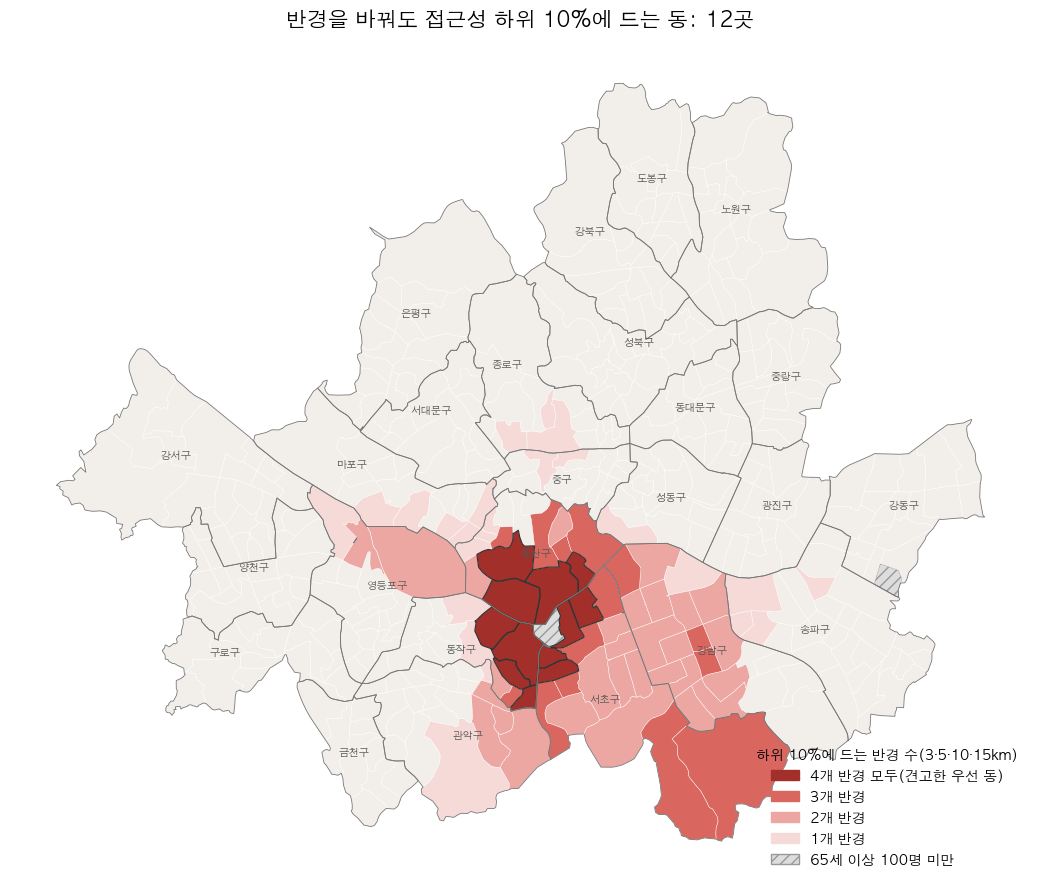

In [12]:
fig, ax = plt.subplots(figsize=(11, 9))
palette = {0: "#F2EFEA", 1: "#F6DAD8", 2: "#EDA7A2", 3: "#D9665F", 4: "#A32F2A"}
for k, color in palette.items():
    part = seoul_dong.loc[seoul_dong["하위10%_반경수"].eq(k) & ~seoul_dong["소수요"]]
    if len(part):
        part.plot(ax=ax, color=color, edgecolor="white", linewidth=0.3)
seoul_dong.loc[seoul_dong["소수요"]].plot(ax=ax, color="#DDDDDD", edgecolor="#999999", hatch="///", linewidth=0.3)
seoul_dong.loc[seoul_dong["행정동코드"].isin(robust)].boundary.plot(ax=ax, color="#333333", linewidth=0.9)
gu_shape = seoul_dong.dissolve(by="지역")
gu_shape.boundary.plot(ax=ax, color="#777777", linewidth=0.6)
for name, geom in gu_shape.geometry.items():
    p = geom.representative_point()
    ax.annotate(name, (p.x, p.y), ha="center", fontsize=7.5, color="#555555")
n_r = len(C.D0_SENSITIVITY_KM)
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[k]) for k in range(n_r, 0, -1)]
handles.append(plt.Rectangle((0, 0), 1, 1, facecolor="#DDDDDD", edgecolor="#999999", hatch="///"))
ax.legend(handles, [f"{n_r}개 반경 모두(견고한 우선 동)"] + [f"{k}개 반경" for k in range(n_r - 1, 0, -1)] + [f"65세 이상 {C.MIN_POP65}명 미만"],
          title=f"하위 10%에 드는 반경 수({'·'.join(map(str, C.D0_SENSITIVITY_KM))}km)", loc="lower right", frameon=False)
ax.set_title(f"반경을 바꿔도 접근성 하위 10%에 드는 동: {len(robust)}곳", fontsize=15, pad=14)
ax.set_axis_off()
plt.tight_layout()
fig.savefig(C.OUTPUT_DIR / "견고한_우선동_지도.png", dpi=200, bbox_inches="tight")
plt.show()

### 8. 자치구 집계와 기존 분석 비교

동별 접근성을 수요 가중 평균으로 자치구에 모으고, 기존 자치구 분석의 주 지표(75세 이상 1,000명당 정원, 구 안의 시설만 계산)와 순위를 비교한다. 두 순위가 크게 다른 구는 이웃 구·경기도 시설 이용이 반영되면서 평가가 달라진 곳이다.

In [13]:
general = pd.read_excel(C.FACILITY_FILE, sheet_name="일반현황", dtype={"장기요양기관코드": str})
capacity = pd.read_excel(C.FACILITY_FILE, sheet_name="입소인원", dtype={"장기요양기관코드": str})
region = general["시도 시군구 법정동명"].str.extract(r"^(\S+)\s+(\S+)")
region_fallback = general["기관별 상세주소"].str.extract(r"^(\S+)\s+(\S+)")
general["시도"] = region[0].fillna(region_fallback[0])
general["지역"] = region[1].fillna(region_fallback[1])
gu_capacity = (
    capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES)]
    .merge(general.loc[general["시도"].eq("서울특별시"), ["장기요양기관코드", "지역"]], on="장기요양기관코드")
    .groupby("지역")["정원"].sum()
)
pop = pd.read_csv(C.OUTPUT_DIR / "행정동_성별_5세_인구.csv", dtype={"행정동코드": str})
pop75 = pop.loc[pop["연령"].ge(75)].merge(seoul_dong[["행정동코드", "지역"]], on="행정동코드").groupby("지역")["인구"].sum()
assert gu_capacity.sum() == 16_055 and pop75.sum() == 729_748

gu = seoul_dong.assign(DA=seoul_dong[DEMAND_COL] * seoul_dong["A100"]).groupby("지역").agg(수요=(DEMAND_COL, "sum"), DA=("DA", "sum"))
gu["유효접근성_100명당"] = gu["DA"] / gu["수요"]
gu["기존_75세이상_천명당_정원"] = gu_capacity / pop75 * 1_000
gu["순위_기존"] = gu["기존_75세이상_천명당_정원"].rank(ascending=False).astype(int)
gu["순위_E2SFCA"] = gu["유효접근성_100명당"].rank(ascending=False).astype(int)
gu["순위변화"] = gu["순위_기존"] - gu["순위_E2SFCA"]
gu["하위10%_동수"] = bottom.groupby("지역").size().reindex(gu.index).fillna(0).astype(int)
gu = gu.sort_values("유효접근성_100명당")
rho_gu = spearmanr(gu["유효접근성_100명당"], gu["기존_75세이상_천명당_정원"])[0]
gu.drop(columns="DA").to_csv(C.OUTPUT_DIR / "자치구별_접근성.csv")

display(Markdown(f"자치구 순위 상관(E2SFCA 수요가중 평균 vs 기존 1,000명당 정원): **{rho_gu:.2f}**"))
display(
    gu[["수요", "유효접근성_100명당", "순위_E2SFCA", "기존_75세이상_천명당_정원", "순위_기존", "순위변화", "하위10%_동수"]]
    .style.format({"수요": "{:,.0f}", "유효접근성_100명당": "{:.1f}", "기존_75세이상_천명당_정원": "{:.1f}"})
    .background_gradient(subset=["순위변화"], cmap="RdBu", vmin=-12, vmax=12)
)

자치구 순위 상관(E2SFCA 수요가중 평균 vs 기존 1,000명당 정원): **0.81**

,수요,유효접근성_100명당,순위_E2SFCA,기존_75세이상_천명당_정원,순위_기존,순위변화,하위10%_동수
지역,,,,,,,
용산구,544,25.0,25,10.1,22,-3,12
서초구,822,31.7,24,11.7,19,-5,8
동작구,918,32.9,23,10.7,21,-2,8
마포구,800,37.5,22,14.5,18,-4,3
강남구,"1,072",38.0,21,8.4,24,3,3
중구,353,41.0,20,7.3,25,5,0
영등포구,865,47.5,19,9.2,23,4,2
성동구,642,49.4,18,19.4,14,-4,0
광진구,712,52.5,17,25.1,10,-7,0


### 9. 보고서 문장

In [14]:
top_gu = bottom.groupby("지역").size().sort_values(ascending=False)
top3 = top_gu.head(3)
rose = gu.sort_values("순위변화").iloc[0]      # 기존보다 순위가 가장 많이 내려간 구(E2SFCA에서 더 부족)
fell = gu.sort_values("순위변화").iloc[-1]     # 기존보다 순위가 가장 많이 오른 구
d0_rows = pivot.loc[pivot["반경(km)"].ne(C.D0_KM)]
SENS_D0 = 10
s10 = seoul_dong.loc[~seoul_dong["소수요"], f"A100_{SENS_D0}km"]
r_names = {g: "·".join(d["행정동명"]) for g, d in robust_table.groupby("지역", sort=False)}
r5 = robust_table[f"A100_{C.D0_KM}km"]
r10 = robust_table[f"A100_{SENS_D0}km"]
sentence = (
    f"이용 반경 {C.D0_KM}km와 시설 품질을 반영한 E2SFCA로 보면, 서울 행정동의 장기요양 1~2등급 인정자 100명당 "
    f"유효 정원은 중앙값 {q50:.1f}석이지만 하위 10% 동은 {q10:.1f}석 이하, 상위 10% 동은 {q90:.1f}석 이상으로 "
    f"{q90 / q10:.1f}배 차이가 난다(반경 {SENS_D0}km에서는 중앙값 {s10.median():.1f}석, 하위 10% {s10.quantile(0.1):.1f}석 이하, "
    f"상위 10% {s10.quantile(0.9):.1f}석 이상). 어느 동이 가장 부족한지는 반경에 따라 달라지므로, 반경을 "
    f"{'·'.join(map(str, C.D0_SENSITIVITY_KM))}km로 바꿔도 모두 하위 10%에 드는 동을 우선 지역으로 삼았다. "
    f"이런 동은 {len(robust_table)}곳으로 "
    + ", ".join(f"{g}({n})" for g, n in r_names.items())
    + f"에 모여 있다. 이 동들의 100명당 유효 정원은 반경 {C.D0_KM}km 기준 {r5.min():.1f}~{r5.max():.1f}석으로 서울 중앙값의 "
    f"{r5.max() / q50:.0%} 이하이고, 반경 {SENS_D0}km 기준으로도 {r10.min():.1f}~{r10.max():.1f}석(서울 중앙값 {s10.median():.1f}석)이다. "
    f"자치구 단위 정원 지표와의 순위 상관은 {rho_gu:.2f}로 큰 흐름은 같지만, "
    f"{rose.name}는 이웃 지역 시설과 수요를 함께 고려하면 순위가 {int(rose['순위_기존'])}위에서 {int(rose['순위_E2SFCA'])}위로 내려가고 "
    f"{fell.name}는 {int(fell['순위_기존'])}위에서 {int(fell['순위_E2SFCA'])}위로 올라간다."
)
display(Markdown(f"> {sentence}"))
print(sentence)

> 이용 반경 5km와 시설 품질을 반영한 E2SFCA로 보면, 서울 행정동의 장기요양 1~2등급 인정자 100명당 유효 정원은 중앙값 67.5석이지만 하위 10% 동은 28.5석 이하, 상위 10% 동은 109.8석 이상으로 3.8배 차이가 난다(반경 10km에서는 중앙값 77.7석, 하위 10% 45.4석 이하, 상위 10% 115.2석 이상). 어느 동이 가장 부족한지는 반경에 따라 달라지므로, 반경을 3·5·10·15km로 바꿔도 모두 하위 10%에 드는 동을 우선 지역으로 삼았다. 이런 동은 12곳으로 동작구(사당2동·사당3동·사당1동·흑석동), 용산구(서빙고동·이촌1동·보광동·한강로동), 서초구(반포2동·방배본동·반포3동·방배4동)에 모여 있다. 이 동들의 100명당 유효 정원은 반경 5km 기준 15.8~25.0석으로 서울 중앙값의 37% 이하이고, 반경 10km 기준으로도 33.7~43.4석(서울 중앙값 77.7석)이다. 자치구 단위 정원 지표와의 순위 상관은 0.81로 큰 흐름은 같지만, 종로구는 이웃 지역 시설과 수요를 함께 고려하면 순위가 5위에서 16위로 내려가고 서대문구는 20위에서 13위로 올라간다.

이용 반경 5km와 시설 품질을 반영한 E2SFCA로 보면, 서울 행정동의 장기요양 1~2등급 인정자 100명당 유효 정원은 중앙값 67.5석이지만 하위 10% 동은 28.5석 이하, 상위 10% 동은 109.8석 이상으로 3.8배 차이가 난다(반경 10km에서는 중앙값 77.7석, 하위 10% 45.4석 이하, 상위 10% 115.2석 이상). 어느 동이 가장 부족한지는 반경에 따라 달라지므로, 반경을 3·5·10·15km로 바꿔도 모두 하위 10%에 드는 동을 우선 지역으로 삼았다. 이런 동은 12곳으로 동작구(사당2동·사당3동·사당1동·흑석동), 용산구(서빙고동·이촌1동·보광동·한강로동), 서초구(반포2동·방배본동·반포3동·방배4동)에 모여 있다. 이 동들의 100명당 유효 정원은 반경 5km 기준 15.8~25.0석으로 서울 중앙값의 37% 이하이고, 반경 10km 기준으로도 33.7~43.4석(서울 중앙값 77.7석)이다. 자치구 단위 정원 지표와의 순위 상관은 0.81로 큰 흐름은 같지만, 종로구는 이웃 지역 시설과 수요를 함께 고려하면 순위가 5위에서 16위로 내려가고 서대문구는 20위에서 13위로 올라간다.


### 해석상 주의

- 거리는 직선거리다. 한강 다리 사이 간격이 넓은 구간의 강변 동(예: 강 건너 시설이 직선으로는 가깝지만 실제 이동은 먼 경우)은 접근성이 과대평가될 수 있다. 도로망 거리(네트워크 분석)로 바꾸는 작업은 후속 과제로 남긴다.
- 수요 지점은 행정동 경계의 기하 중심이다. 산지가 넓은 동은 실제 거주지와 중심점이 떨어져 있을 수 있다.
- 버퍼 지역(경기·인천)의 수요는 서울 인정률로 추정했다(버전 A). 버퍼 시설을 서울 주민이 실제로 얼마나 이용하는지는 자료로 확인할 수 없다.
- 입소시설은 가족의 거주지·직장 근처를 고르는 경우도 많아, 반경 가정은 4단계에서 만실 여부로 검증한다.

### 출처

- Luo, W., & Qi, Y. (2009). An enhanced two-step floating catchment area (E2SFCA) method for measuring spatial accessibility to primary care physicians. *Health & Place*, 15(4), 1100–1107.
- 자료: 01~03 노트북 산출물